In [1]:
import pandas as pd
import numpy as np
import faiss

In [2]:
df = pd.read_csv('./creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
X = df.drop(['Time', 'Class'], axis=1).values
y = df['Class'].values
X, y

#### Find non-fraud and fraud indices

normal_idx = np.where(y == 0)[0]
fraud_idx = np.where(y == 1)[0]

np.random.seed(42)
np.random.shuffle(normal_idx)

train_idx = normal_idx[ : 200000]
test_normal_idx = normal_idx[200000 : ]
test_idx = np.concatenate([test_normal_idx, fraud_idx])

X_train = X[train_idx]
X_test = X[test_idx]
y_test = y[test_idx]
X_train.shape, X_test.shape, y_test.shape

## Calculate mean and std

mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)

std[std == 0] = 1e-10

X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std

X_train_scaled = np.ascontiguousarray(X_train_scaled, dtype=np.float32)
X_test_scaled = np.ascontiguousarray(X_test_scaled, dtype=np.float32)

## index.search(X_test_scaled, k) returns a distance and indices matrices.

#### distance matrix denotes
- a single row represents list of distances to k train points that this test point is closest to.

#### indices = [[ 802,  41,   19902 ]] 
- 802 (The closest neighbor): If you  open your X_train dataset (the 200,000 normal transactions) and scroll down to Row 802, that specific transaction is the single most mathematically similar event to your test point.
- 41 (The 2nd closest): Scroll up to Row 41 in your training data. That is the 2nd closest match.
- 19902 (The 3rd closest): Scroll down to Row 19,902. That is the 3rd closest match.

In [4]:
## Building the HNSW Index
# This is where the magic happens. Instead of a KD-Tree, we are building a Hierarchical Navigable Small World (HNSW) graph. It organizes the data into layers of connected nodes, similar to how human social networks operate.

no_of_features = X_train_scaled.shape[1]
index = faiss.IndexHNSWFlat(no_of_features, 32)
index.add(X_train_scaled)

# FORCE FAISS to be more accurate (Default is usually 16, let's make it 256)
index.hnsw.efSearch = 256

# Increase 'k' to account for the extreme density of 200,000 points
k = 100
distances, indices = index.search(X_test_scaled, k)

anomaly_scores = distances[:, k-1]

def evaluate(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return precision, recall, f1_score
    
print("\n--- FAISS Anomaly Detection Results (Tuned) ---")

for percentile in [98.0, 99.0, 99.5, 99.8]:
    threshold = np.percentile(anomaly_scores, percentile)
    predictions = (anomaly_scores > threshold).astype(int)
    
    precision, recall, f1 = evaluate(y_test, predictions)
    print(f"Threshold: {percentile}th Percentile (Squared Distance: {threshold:.2f})")
    print(f"Precision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f}\n")


--- FAISS Anomaly Detection Results (Tuned) ---
Threshold: 98.0th Percentile (Squared Distance: 55.33)
Precision: 0.242 | Recall: 0.833 | F1: 0.375

Threshold: 99.0th Percentile (Squared Distance: 110.16)
Precision: 0.442 | Recall: 0.762 | F1: 0.559

Threshold: 99.5th Percentile (Squared Distance: 258.86)
Precision: 0.614 | Recall: 0.530 | F1: 0.569

Threshold: 99.8th Percentile (Squared Distance: 850.43)
Precision: 0.712 | Recall: 0.246 | F1: 0.366



In [5]:
distances, indices

(array([[1.1595814e+00, 2.4325497e+00, 2.6188257e+00, ..., 6.5711970e+00,
         6.5819860e+00, 6.6140037e+00],
        [3.0466220e+00, 4.4176822e+00, 7.0524368e+00, ..., 1.6903587e+01,
         1.6960659e+01, 1.7016106e+01],
        [2.7735871e-01, 4.4620618e-01, 6.9706738e-01, ..., 5.7762408e+00,
         5.7825046e+00, 5.8305140e+00],
        ...,
        [6.5251297e+01, 9.4838081e+01, 9.4878784e+01, ..., 9.8453300e+01,
         9.8470970e+01, 9.8527863e+01],
        [4.1941776e+01, 6.3619766e+01, 1.0456837e+02, ..., 1.8853831e+02,
         1.8855185e+02, 1.8857259e+02],
        [1.8471864e-01, 1.5554422e+00, 1.6760329e+00, ..., 4.0971241e+00,
         4.1008339e+00, 4.1152101e+00]], shape=(84807, 100), dtype=float32),
 array([[ 64865, 161675,  55237, ..., 191114, 190542, 152036],
        [131792,  86445, 175170, ..., 162474, 155979,  60323],
        [ 34606, 188379,   4890, ...,  95044,  26315,  75623],
        ...,
        [ 14224,  20752, 139968, ...,  21983,  46965,  14203],
 

#### Understanding the Trade-off

Every single point on that curve represents a specific distance threshold.

- If you set the distance threshold very low, you flag almost everything as fraud. Your Recall will be 1.0 (you caught 100% of frauds), but your Precision will plummet close to 0 (you flagged millions of innocent users).

- If you set the distance threshold very high, you only flag things you are absolutely certain about. Your Precision will be close to 1.0 (no false alarms), but your Recall will drop because you missed the sneakier frauds.

In [ ]:
normal_idx = np.where(y == 0)[0]
fraud_idx = np.where(y == 1)[0]

np.random.seed(42)
np.random.shuffle(normal_idx)

train_idx = normal_idx[ : 200000]
test_normal_idx = normal_idx[200000 : ]
test_idx = np.concatenate([test_normal_idx, fraud_idx])

X_train = X[train_idx]
X_test = X[test_idx]
y_test = y[test_idx]

## Calculate mean and std

mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)

std[std == 0] = 1e-10

X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std

X_train_scaled = np.ascontiguousarray(X_train_scaled, dtype=np.float32)
X_test_scaled = np.ascontiguousarray(X_test_scaled, dtype=np.float32)

Area Under the Precision-Recall Curve (AUPRC): 0.5066


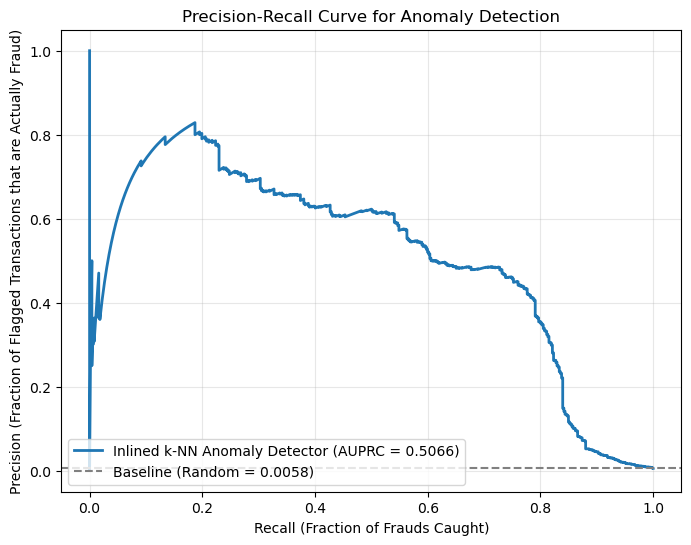

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

# 1. Get your anomaly scores (Euclidean distances from your test points)
# Assuming 'anomaly_scores' contains the distance to the k-th neighbor
# and 'y_test' contains the actual labels (0 for normal, 1 for fraud)

# 2. Compute Precision and Recall for all possible thresholds
# Note: Since higher distances mean HIGHER probability of fraud, 
# we pass the raw anomaly scores directly.
precision, recall, thresholds = precision_recall_curve(y_test, anomaly_scores)

# 3. Calculate the Area Under the Curve (AUPRC)
auprc_score = auc(recall, precision)
print(f"Area Under the Precision-Recall Curve (AUPRC): {auprc_score:.4f}")

# 4. Plot the AUPRC Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Inlined k-NN Anomaly Detector (AUPRC = {auprc_score:.4f})', linewidth=2)

# Plot a baseline horizontal line representing a random classifier
# A random classifier's precision is equal to the proportion of positive cases
baseline = np.sum(y_test == 1) / len(y_test)
plt.axhline(y=baseline, color='gray', linestyle='--', label=f'Baseline (Random = {baseline:.4f})')

plt.xlabel('Recall (Fraction of Frauds Caught)')
plt.ylabel('Precision (Fraction of Flagged Transactions that are Actually Fraud)')
plt.title('Precision-Recall Curve for Anomaly Detection')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.savefig('auprc_faiss.png')
plt.show()

## Explain Anomaly

In [7]:
df.drop(['Time', 'Class'], axis=1).columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount'],
      dtype='str')

In [18]:
feature_names = df.drop(['Time', 'Class'], axis=1).columns

def explain_anomaly(test_index, k=100):
    # grab the scaled test point and reshape the matrix to be 1 row and 28 column values (1, 28)
    test_point = X_test_scaled[test_index].reshape(1, -1)

    # grab the distances and indices of those test points that are nearer.
    distances, indices = index.search(test_point, k)

    # get the indices of k-1th col index so that we can grab it from X_train scaled class
    neighbour = indices[0][k-1]
    normal_neighbour = X_train_scaled[neighbour]

    squared_differences = (test_point[0] - normal_neighbour) ** 2

    # np.argsort sorts the elements smalles to largest but stores their order in values of their indices.
    sorted_feature_indices = np.argsort(squared_differences)[::-1]

    print(f"--- ANOMALY EXPLANATION REPORT ---")
    print(f"Test Transaction Index: {test_index}")
    print(f"Total Anomaly Score: {distances[0][k-1]:.2f}\n")
    print("Top 5 Feature Culprits (What made this look like fraud):")

    top_features = []
    top_contributions = []
    
    for i in range(5):
        feature_index = sorted_feature_indices[i]
        feature_name = feature_names[i]

        score = squared_differences[feature_index]
        contribution = (score / np.sum(squared_differences)) * 100

        print(f"{i+1}. {feature_name}: Contributed {score:.2f} ({contribution:.1f}% of anomaly)")

        top_features.append(feature_name)
        top_contributions.append(contribution)

    plt.figure(figsize=(8, 4))
    plt.barh(top_features[::-1], top_contributions[::-1], color='crimson')
    plt.xlabel('Squared Distance Contribution')
    plt.title('Top 5 Anomaly Drivers')
    plt.tight_layout()
    plt.savefig('top_5_anomaly_drivers.png')
    plt.show()

## Explain_function elaborated

In [12]:
# assigning 0th index here directly changes array_shape. Hence, Not feasible
test_point = X_test_scaled[one_sample_fraud].reshape(1, -1) 
test_point[0], test_point.shape

(array([-1.197622  ,  1.1937996 , -1.1102437 ,  2.8632996 , -0.38741416,
        -1.0710937 , -2.1421807 ,  1.1977253 , -2.5492036 , -2.6673918 ,
         3.2029068 , -3.083422  , -0.598092  , -4.7954803 ,  0.4240657 ,
        -1.3579531 , -3.809134  , -0.02467039,  0.5146072 ,  0.16602857,
         0.717839  , -0.04877728, -0.748865  ,  0.52863836,  0.08693407,
         0.36908394,  0.6479053 , -0.43611902, -0.34925282], dtype=float32),
 (1, 29))

In [13]:
distances, indices = index.search(test_point, k)
distances, indices

(array([[28.84007 , 82.89939 , 83.95272 , 83.96595 , 84.11915 , 84.14997 ,
         84.2783  , 84.66296 , 84.66816 , 84.71364 , 84.75391 , 85.05407 ,
         85.11982 , 85.12317 , 85.19262 , 85.319305, 85.37111 , 85.46667 ,
         85.49906 , 85.55428 , 85.59041 , 85.783875, 85.802086, 85.81847 ,
         85.86486 , 85.952484, 86.13729 , 86.206924, 86.24353 , 86.25781 ,
         86.28302 , 86.29996 , 86.30378 , 86.34093 , 86.41571 , 86.470505,
         86.49709 , 86.50317 , 86.50577 , 86.511734, 86.57512 , 86.59157 ,
         86.60733 , 86.643745, 86.64721 , 86.64916 , 86.68539 , 86.722374,
         86.72568 , 86.760506, 86.764984, 86.85979 , 86.86572 , 86.8979  ,
         86.902855, 86.922356, 86.96086 , 86.97967 , 86.99209 , 87.01911 ,
         87.02478 , 87.07385 , 87.1059  , 87.128426, 87.13055 , 87.1306  ,
         87.140305, 87.153175, 87.16042 , 87.16043 , 87.17291 , 87.17546 ,
         87.19228 , 87.20751 , 87.20751 , 87.21936 , 87.23274 , 87.23274 ,
         87.233444, 87.23

In [14]:
neighbour = indices[0][k-1]
normal_neighbour = X_train_scaled[neighbour]

In [15]:
sq_differences= (test_point[0] - normal_neighbour) ** 2
sq_differences, np.sum(sq_differences)

(array([1.02088785e+00, 3.76802295e-01, 5.13157654e+00, 1.18833685e+00,
        4.31492776e-01, 2.12149858e+00, 7.56785870e+00, 1.33321238e+00,
        2.61377001e+00, 7.65953207e+00, 5.30764008e+00, 1.04747477e+01,
        2.06486806e-01, 1.02402525e+01, 2.03910112e+00, 4.41082764e+00,
        1.86109638e+01, 6.52873397e-01, 4.75501700e-04, 3.28737423e-02,
        1.36409640e+00, 1.24439394e+00, 7.61951089e-01, 5.69823325e-01,
        2.66952425e-01, 7.39713311e-01, 8.90761077e-01, 3.42926476e-03,
        8.16331208e-02], dtype=float32),
 np.float32(87.34397))

In [16]:
sorted_feature_indices = np.argsort(sq_differences)[::-1]
sorted_feature_indices

array([16, 11, 13,  9,  6, 10,  2, 15,  8,  5, 14, 20,  7, 21,  3,  0, 26,
       22, 25, 17, 23,  4,  1, 24, 12, 28, 19, 27, 18])

In [17]:
distances[0][k-1]

np.float32(87.34396)

### Explain Anomaly Function Call

--- ANOMALY EXPLANATION REPORT ---
Test Transaction Index: 84315
Total Anomaly Score: 87.34

Top 5 Feature Culprits (What made this look like fraud):
1. V1: Contributed 18.61 (21.3% of anomaly)
2. V2: Contributed 10.47 (12.0% of anomaly)
3. V3: Contributed 10.24 (11.7% of anomaly)
4. V4: Contributed 7.66 (8.8% of anomaly)
5. V5: Contributed 7.57 (8.7% of anomaly)


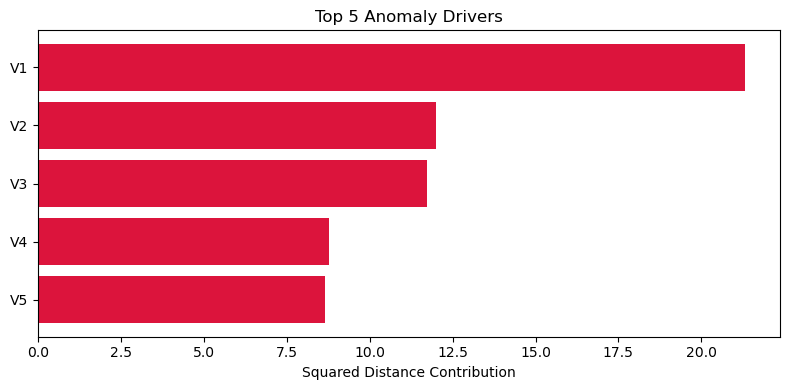

In [19]:
fraud_indices = np.where(y_test == 1)[0]
one_sample_fraud = fraud_indices[0]
one_sample_fraud

explain_anomaly(one_sample_fraud, k=100)

# Export model artifacts

In [ ]:
import pickle as pkl

model_artifacts = {
    "mean": mean,
    "std": std
}

with open("model_artifacts.pkl", 'wb') as file:
    pkl.dump(model_artifacts, file)

faiss.write_index(index, 'fraud_faiss_index.bin')

print("Model artifacts and index saved successfully")